# Introduction to Matplotlib

## Visualization with Matplotlib

### General Matplotlib Tips

- Before we dive into the details of creating visualizations with Matplotlib, there are a few useful things you should know about using the package.

#### Importing Matplotlib

- Just as we use the np shorthand for NumPy and the pd shorthand for Pandas, we will use some standard shorthands for Matplotlib imports:

In [1]:
import matplotlib.pyplot as plt

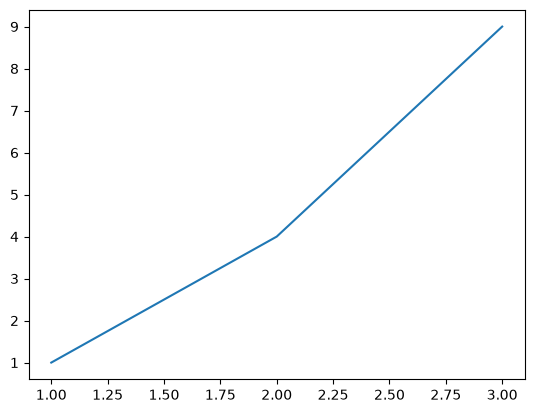

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot([1, 2, 3], [1, 4, 9])
plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [8]:
df = pd.read_csv('./data/Superstore (1).csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1.0,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2.0,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3.0,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4.0,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5.0,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.isnull().sum()

Row ID           194
Order ID         194
Order Date       194
Ship Date        194
Ship Mode        194
Customer ID      194
Customer Name    194
Segment          194
Country          194
City             194
State            194
Postal Code      205
Region           194
Product ID       194
Category         194
Sub-Category     194
Product Name     194
Sales            194
Quantity           0
Discount           0
Profit             0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### Single Variable (Univariate)

#### Matlab Style Interface

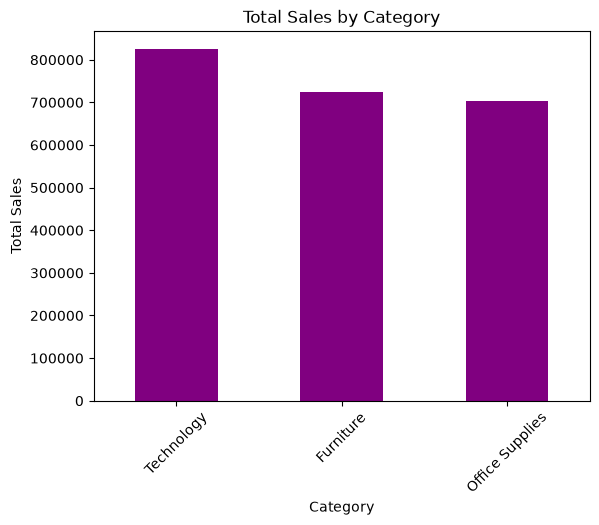

In [35]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sales_by_category.plot(kind='bar', color='purple')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.show()

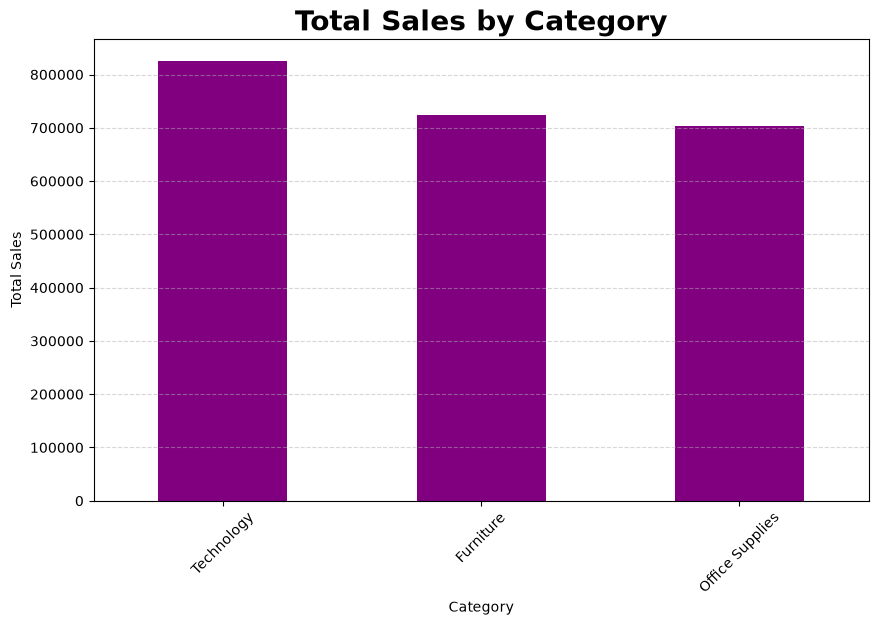

In [36]:
sales_by_category

fig, ax = plt.subplots(figsize=(10, 6))

ax = sales_by_category.plot(kind='bar', color='purple')

ax.set_title('Total Sales by Category', fontsize=20, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales')

#  adding gridlines
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.xticks(rotation=45)
plt.show()

### Sales by Segment - Pie Chart

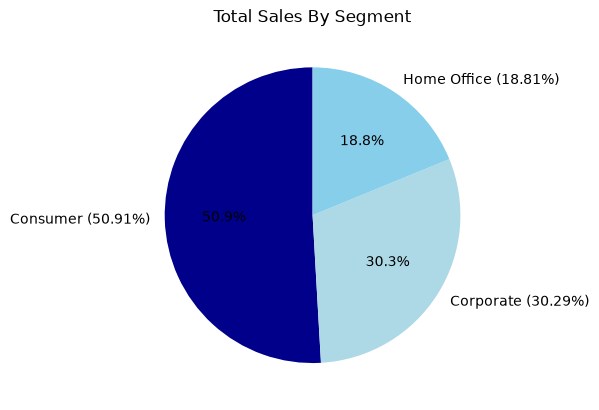

In [50]:
sales_by_segment = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

total = sales_by_segment.sum()
percentages = (sales_by_segment / total) * 100
percentages

# build the custom labels
labels = [f'{seg} ({pct}%)' for seg, pct in zip(sales_by_segment.index, percentages.round(2))]

sales_by_segment.plot(
    kind='pie',
    startangle=90,
    labels=labels,
    title='Total Sales By Segment',
    colors = ['darkblue', 'lightblue', 'skyblue'],
    autopct='%1.1f%%',
)

plt.show()

### Histogram Distribution of Sales

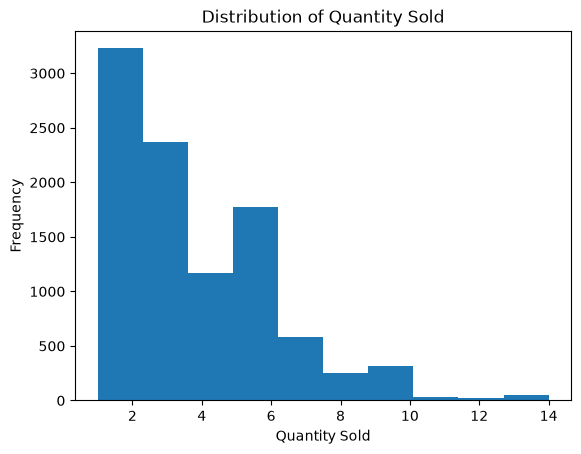

In [60]:
# df['Quantity'].plot(kind='hist', title='Distribution of Quantity Sold')

plt.hist(df['Quantity'])
plt.title('Distribution of Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Frequency')
plt.show()

### Top 10 Customers by Sales

In [77]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

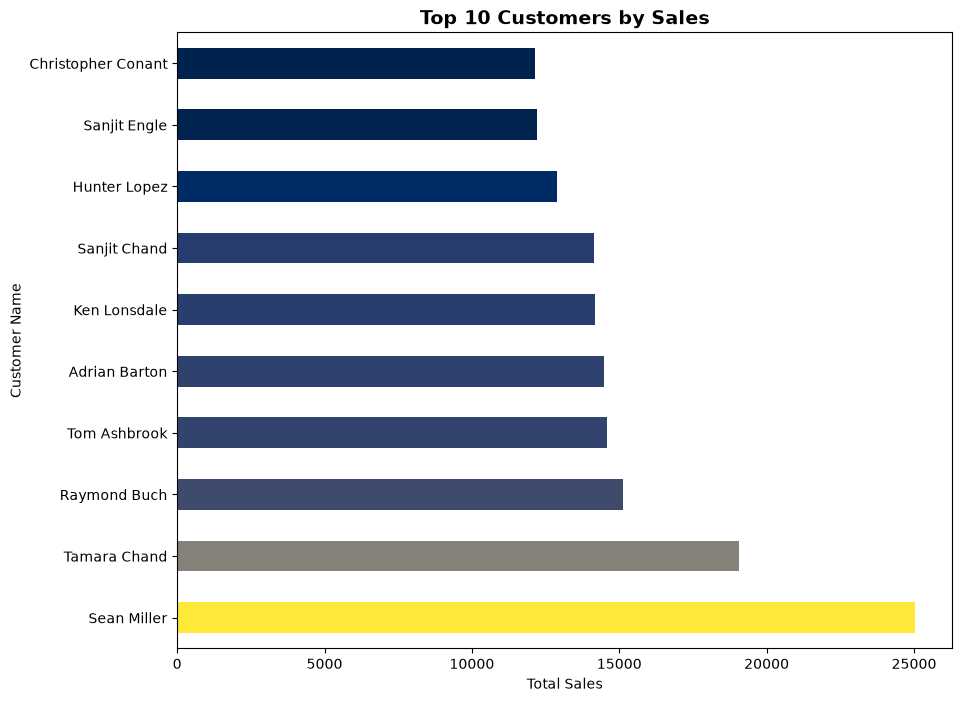

In [91]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
# top_customers.plot(kind='barh', title='Top 10 Customers by Sales')

# Normalize the sales for color mapping
norm = mcolors.Normalize(vmin=top_customers.min(), vmax=top_customers.max())
colors = cm.cividis(norm(top_customers.values))

# Plot the bar chart
ax = top_customers.plot(
    kind='barh', 
    color=colors,
    figsize=(10, 8),
)

# customize the plot
ax.set_title('Top 10 Customers by Sales', fontweight='bold', fontsize=14)
ax.set_xlabel('Total Sales')
ax.set_ylabel('Customer Name')
plt.show()

## Scatter Plot - Sales vs. Profit

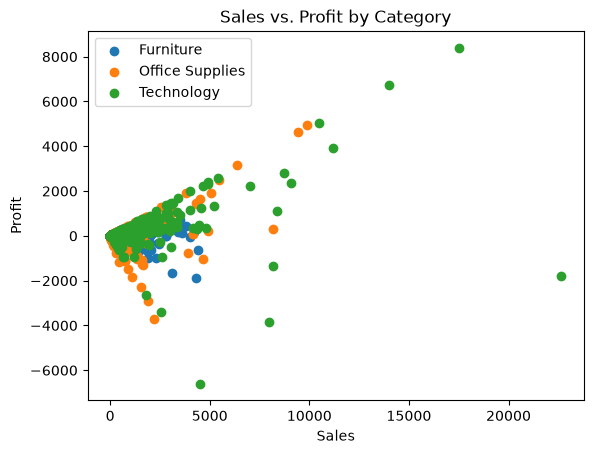

In [95]:
category = df['Category'].unique()

for cat in category:
    subset = df[df['Category'] == cat]
    plt.scatter(subset['Sales'], subset['Profit'], label=cat)

plt.title('Sales vs. Profit by Category')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.legend(
    loc='upper left',
)

## Time Series

### Sales Over Time

In [96]:
df.info()

<class 'pandas.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9789 non-null   float64
 1   Order ID       9789 non-null   str    
 2   Order Date     9789 non-null   str    
 3   Ship Date      9789 non-null   str    
 4   Ship Mode      9789 non-null   str    
 5   Customer ID    9789 non-null   str    
 6   Customer Name  9789 non-null   str    
 7   Segment        9789 non-null   str    
 8   Country        9789 non-null   str    
 9   City           9789 non-null   str    
 10  State          9789 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9789 non-null   str    
 13  Product ID     9789 non-null   str    
 14  Category       9789 non-null   str    
 15  Sub-Category   9789 non-null   str    
 16  Product Name   9789 non-null   str    
 17  Sales          9789 non-null   float64
 18  Quantity       9789 non-

In [100]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

In [101]:
df.info()

<class 'pandas.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   float64       
 1   Order ID       9789 non-null   str           
 2   Order Date     9789 non-null   datetime64[us]
 3   Ship Date      9789 non-null   datetime64[us]
 4   Ship Mode      9789 non-null   str           
 5   Customer ID    9789 non-null   str           
 6   Customer Name  9789 non-null   str           
 7   Segment        9789 non-null   str           
 8   Country        9789 non-null   str           
 9   City           9789 non-null   str           
 10  State          9789 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9789 non-null   str           
 13  Product ID     9789 non-null   str           
 14  Category       9789 non-null   str           
 15  Sub-Category   9789 non-null   str   

In [102]:
# set order date as index
df.set_index('Order Date', inplace=True)

In [103]:
df.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2017-11-08,1.0,CA-2017-152156,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2017-11-08,2.0,CA-2017-152156,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2017-06-12,3.0,CA-2017-138688,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
2016-10-11,4.0,US-2016-108966,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
2016-10-11,5.0,US-2016-108966,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [104]:
df.loc['2016-10-11']

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2016-10-11,4.0,US-2016-108966,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
2016-10-11,5.0,US-2016-108966,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
2016-10-11,5345.0,CA-2016-112053,2016-10-13,Second Class,SH-20395,Shahid Hopkins,Consumer,United States,Rochester,New York,14609.0,East,TEC-AC-10002550,Technology,Accessories,Memorex 25GB 6X Branded Blu-Ray Recordable Dis...,31.9500,1,0.00,2.2365


#### Resample Sales by Month and Plot

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Order Date', ylabel='Sales'>

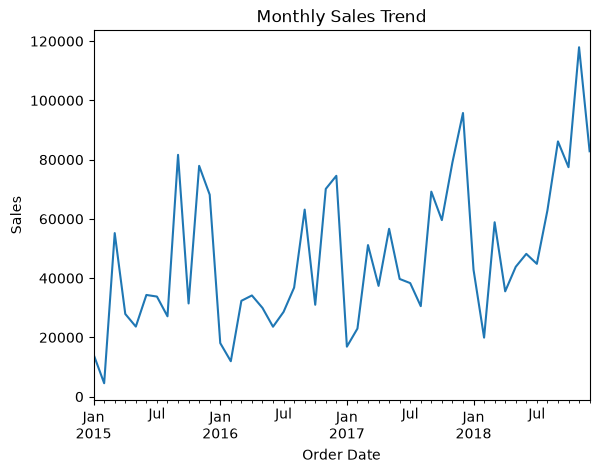

In [112]:
monthly_sales = df['Sales'].resample('ME').sum()
monthly_sales.plot(title='Monthly Sales Trend', ylabel='Sales')

